Topics: Graph classification

* Graph data preparation (Part 0)
* Graph classification (Part 1)
* Model saving and reuse (Part 2)
* Autoencoder for similarity computation (Part 3)

# Part 0: Graph data preparation

In [ ]:
!pip install -q torch-geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 35.7 MB/s eta 0:00:00


[(0, {'price': 28}), (1, {'price': 15}), (2, {'price': 9}), (3, {'price': 14})]
Data(edge_index=[2, 6], price=[4], num_nodes=4, x=[4, 1], y=[1, 1])


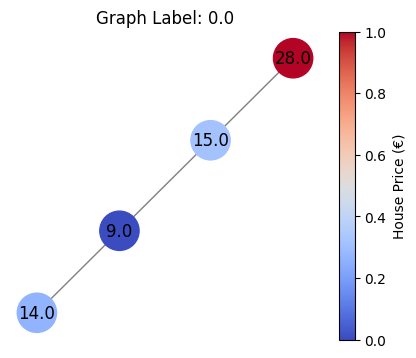

In [ ]:
import random
import torch
import networkx as nx
import matplotlib.pyplot as plt
from torch_geometric.utils import from_networkx
import statistics

def generate_one_graph():
    #num_nodes = random.randint(2, 5)
    num_nodes = 4

    G = nx.path_graph(num_nodes) # see https://networkx.org/documentation/stable/reference/generators.html

    # add prices to each node
    for node in G.nodes():
        G.nodes[node]["price"] = random.randint(1, 50)

    ## convert the graph information to data ready to use by Pytorch Geometric
    data = from_networkx(G)

    # convert price attribute to node feature tensor [num_nodes, 1]
    data.x = torch.tensor([[G.nodes[i]["price"]] for i in G.nodes()],
        dtype=torch.float)

    prices = [G.nodes[n]['price'] for n in G.nodes()]

    label = 1 if sum(prices) >= 80 else 0
    #label = 1 if statistics.mean(prices) >= 30 else 0
    #label = 1 if G.number_of_nodes() >= 4  else 0 # works more or less nicely

    y = torch.tensor([[label]], dtype=torch.float)

    data.y = y

    return G, data

def visualize_graph(G, graph_label=None):
    pos = nx.spring_layout(G, seed=42)

    prices = [G.nodes[n]['price'] for n in G.nodes()]
    labels = {i: f"{prices[i]:.1f}" for i in range(len(prices))}

    node_colors = [G.nodes[n]['price'] for n in G.nodes()]
    fig, ax = plt.subplots(figsize=(5, 4))

    nx.draw(
        G,
        pos,
        node_color=node_colors,
        cmap=plt.cm.coolwarm,
        node_size=800,
        edge_color="gray",
        with_labels=False
    )
    nx.draw_networkx_labels(G, pos, labels=labels)

    cbar = plt.colorbar(
        plt.cm.ScalarMappable(cmap=plt.cm.coolwarm),
        ax=ax,
        label="House Price (€)"
    )

    if graph_label is not None:
        plt.title(f"Graph Label: {graph_label}")
    else:
        plt.title("Fully Connected Graph\n(Node label = price)")
    plt.axis("off")
    plt.show()


def generate_many_graphs(ngraph):

  n_pos = 0
  n_neg = 0
  limit = int(ngraph/2)
  graphs = []
  dataset = []


  while n_pos < limit or n_neg < limit:
    G, data = generate_one_graph()

    if data.y == 1 and n_pos <limit:
      n_pos += 1
      graphs.append(G)
      dataset.append(data)

    elif data.y == 0 and n_neg < limit:
      n_neg += 1
      graphs.append(G)
      dataset.append(data)

  return graphs, dataset


G, data = generate_one_graph()
print(G.nodes(data=True))
print(data)
visualize_graph(G,  graph_label=data.y.item())

Dataset: [Data(edge_index=[2, 6], price=[4], num_nodes=4, x=[4, 1], y=[1, 1]), Data(edge_index=[2, 6], price=[4], num_nodes=4, x=[4, 1], y=[1, 1]), Data(edge_index=[2, 6], price=[4], num_nodes=4, x=[4, 1], y=[1, 1]), Data(edge_index=[2, 6], price=[4], num_nodes=4, x=[4, 1], y=[1, 1]), Data(edge_index=[2, 6], price=[4], num_nodes=4, x=[4, 1], y=[1, 1]), Data(edge_index=[2, 6], price=[4], num_nodes=4, x=[4, 1], y=[1, 1]), Data(edge_index=[2, 6], price=[4], num_nodes=4, x=[4, 1], y=[1, 1]), Data(edge_index=[2, 6], price=[4], num_nodes=4, x=[4, 1], y=[1, 1]), Data(edge_index=[2, 6], price=[4], num_nodes=4, x=[4, 1], y=[1, 1]), Data(edge_index=[2, 6], price=[4], num_nodes=4, x=[4, 1], y=[1, 1]), Data(edge_index=[2, 6], price=[4], num_nodes=4, x=[4, 1], y=[1, 1]), Data(edge_index=[2, 6], price=[4], num_nodes=4, x=[4, 1], y=[1, 1]), Data(edge_index=[2, 6], price=[4], num_nodes=4, x=[4, 1], y=[1, 1]), Data(edge_index=[2, 6], price=[4], num_nodes=4, x=[4, 1], y=[1, 1]), Data(edge_index=[2, 6], 

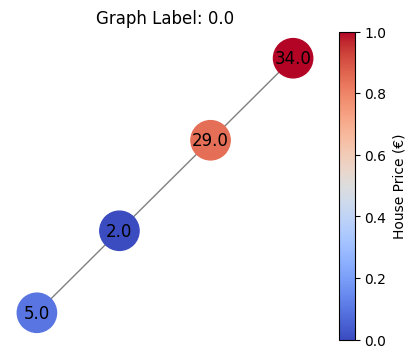

In [ ]:
# Generate 200 graphs
n_graphs = 200
graphs, dataset = generate_many_graphs(n_graphs)

print(f'Dataset: {dataset}:')
print('====================')
print(f'Number of graphs: {len(dataset)}')

data = dataset[0]  # Get the first graph object.

# Gather some statistics about the first graph.
print(f'Number of nodes: {data.num_nodes}')
print(f'Number of edges: {data.num_edges}')
print(f'Average node degree: {data.num_edges / data.num_nodes:.2f}')
print(f'Has isolated nodes: {data.has_isolated_nodes()}')
print(f'Has self-loops: {data.has_self_loops()}')
print(f'Is undirected: {data.is_undirected()}')
print(f'Features: {data.x.T}')
print(f'Label: {data.y.item()}')
visualize_graph(graphs[0], graph_label=dataset[0].y.item())

In [ ]:
import random

torch.manual_seed(12345)

split = int(n_graphs * 80/100)


train_dataset = dataset[:split]
test_dataset = dataset[split:]

print(f'Number of training graphs: {len(train_dataset)}')
print(f'Number of test graphs: {len(test_dataset)}')

from torch_geometric.loader import DataLoader

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print('\n')
for step, data in enumerate(train_loader):
    print(f'Step {step + 1}:')
    print('=======')
    print(f'Number of graphs in the current batch: {data.num_graphs}')
    print(data)
    print()

Number of training graphs: 160
Number of test graphs: 40


Step 1:
Number of graphs in the current batch: 32
DataBatch(edge_index=[2, 192], price=[128], num_nodes=128, x=[128, 1], y=[32, 1], batch=[128], ptr=[33])

Step 2:
Number of graphs in the current batch: 32
DataBatch(edge_index=[2, 192], price=[128], num_nodes=128, x=[128, 1], y=[32, 1], batch=[128], ptr=[33])

Step 3:
Number of graphs in the current batch: 32
DataBatch(edge_index=[2, 192], price=[128], num_nodes=128, x=[128, 1], y=[32, 1], batch=[128], ptr=[33])

Step 4:
Number of graphs in the current batch: 32
DataBatch(edge_index=[2, 192], price=[128], num_nodes=128, x=[128, 1], y=[32, 1], batch=[128], ptr=[33])

Step 5:
Number of graphs in the current batch: 32
DataBatch(edge_index=[2, 192], price=[128], num_nodes=128, x=[128, 1], y=[32, 1], batch=[128], ptr=[33])



# Part 1: Graph classification

In [ ]:
%load_ext tensorboard

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


In [ ]:
import torch
from torch.utils.tensorboard import SummaryWriter
writer = SummaryWriter()

In [ ]:
# https://pytorch-geometric.readthedocs.io/en/2.5.1/cheatsheet/gnn_cheatsheet.html#graph-neural-network-operators
import torch.nn as nn
from torch_geometric.nn import GCNConv, GINConv
import torch.nn.functional as F
from torch_geometric.nn import global_add_pool, global_mean_pool, global_max_pool


class GCN_Graph_Classifier(nn.Module):
    def __init__(self, num_node_features, hidden_channels, num_target_classes):
        super().__init__()
        self.conv1 = GCNConv(num_node_features, hidden_channels)

        self.mlp = nn.Sequential(
            nn.Linear(num_node_features, num_node_features * 100),
            nn.ReLU(),
            nn.Linear(num_node_features * 100, hidden_channels),
        )

        self.gin1 = GINConv(self.mlp, train_eps=True)

        self.lin = nn.Linear(hidden_channels, num_target_classes)

    def forward(self, x, edge_index, batch):

        # 1. node embedding
        h = self.conv1(x, edge_index)
        #h = self.gin1(x, edge_index)
        h = h.relu()

        #print("ne ", h.shape)

        # 2. graph embedding / readout layer
        graph_embedding = global_add_pool(h, batch)  # [batch_size, hidden_channels]
        #print("ge ", graph_embedding.shape)

        # 3. classification
        #graph_embedding = F.dropout(graph_embedding, p=0.5, training=self.training)
        predicted_logits = self.lin(graph_embedding)

        return predicted_logits, graph_embedding, h

gc_model = GCN_Graph_Classifier(1, 50, 1)
print(gc_model)

GCN_Graph_Classifier(
  (conv1): GCNConv(1, 50)
  (mlp): Sequential(
    (0): Linear(in_features=1, out_features=100, bias=True)
    (1): ReLU()
    (2): Linear(in_features=100, out_features=50, bias=True)
  )
  (gin1): GINConv(nn=Sequential(
    (0): Linear(in_features=1, out_features=100, bias=True)
    (1): ReLU()
    (2): Linear(in_features=100, out_features=50, bias=True)
  ))
  (lin): Linear(in_features=50, out_features=1, bias=True)
)


In [ ]:
optimizer = torch.optim.Adam(gc_model.parameters(), lr=0.01)
loss_function = torch.nn.BCEWithLogitsLoss()

def train():
    gc_model.train()

    for data in train_loader:  # iterate in batches over the training dataset
         predicted_logits, ge, ne = gc_model(data.x, data.edge_index, data.batch)  # perform a single forward pass
         #print(out.shape, data.y.shape)
         loss = loss_function(predicted_logits, data.y)  # compute the loss
         optimizer.zero_grad()  # clear gradients
         loss.backward()  # initiate backpropagation: compute the gradient of the loss function for all model parameters
         optimizer.step()  # update weights and biases based on gradients

         writer.add_scalar("loss", loss, epoch)


def test(loader):
     gc_model.eval()

     correct = 0
     for data in loader:  # iterate in batches over the training/test dataset
         predicted_logits, ge, ne = gc_model(data.x, data.edge_index, data.batch)
         #print(out.T, torch.sigmoid(out).T)
         pred_label = torch.round(torch.sigmoid(predicted_logits))  # convert logits to probabilities and then probalities to class labels
        # print(pred.shape, data.y.shape)
         #print("Test progress: -- pred", pred.T, " true -", data.y.T)
         correct += int((pred_label == data.y).sum())  # check against ground-truth labels
     return correct / len(loader.dataset)  # derive ratio of correct predictions

epochs = 500
for epoch in range(epochs):
    train()
    train_acc = test(train_loader)
    test_acc = test(test_loader)
    writer.add_scalar("train-acc", train_acc, epoch)
    writer.add_scalar("test-acc", test_acc, epoch)

    if (epoch) % 10 == 0 or epoch == 0:
      print(f'Epoch: {epoch:03d}, Train Acc: {train_acc:.4f}, Test Acc: {test_acc:.4f}')

Epoch: 000, Train Acc: 0.8250, Test Acc: 0.7000
Epoch: 010, Train Acc: 0.9750, Test Acc: 1.0000
Epoch: 020, Train Acc: 0.9688, Test Acc: 1.0000
Epoch: 030, Train Acc: 0.9500, Test Acc: 1.0000
Epoch: 040, Train Acc: 0.9750, Test Acc: 1.0000
Epoch: 050, Train Acc: 0.9625, Test Acc: 1.0000
Epoch: 060, Train Acc: 0.9563, Test Acc: 0.9750
Epoch: 070, Train Acc: 0.9750, Test Acc: 1.0000
Epoch: 080, Train Acc: 0.9688, Test Acc: 1.0000
Epoch: 090, Train Acc: 0.9625, Test Acc: 0.9750
Epoch: 100, Train Acc: 0.9313, Test Acc: 0.9250
Epoch: 110, Train Acc: 0.9688, Test Acc: 1.0000
Epoch: 120, Train Acc: 0.9750, Test Acc: 1.0000
Epoch: 130, Train Acc: 0.9750, Test Acc: 1.0000
Epoch: 140, Train Acc: 0.9625, Test Acc: 0.9750
Epoch: 150, Train Acc: 0.9500, Test Acc: 0.9250
Epoch: 160, Train Acc: 0.9500, Test Acc: 1.0000
Epoch: 170, Train Acc: 0.9688, Test Acc: 1.0000
Epoch: 180, Train Acc: 0.9750, Test Acc: 1.0000
Epoch: 190, Train Acc: 0.9750, Test Acc: 1.0000
Epoch: 200, Train Acc: 0.9500, Test Acc:

In [ ]:
writer.flush()
writer.close()

In [ ]:
!kill 1845

/bin/bash: line 1: kill: (1845) - No such process


In [ ]:
%tensorboard --logdir runs

# Part 2: Save and reuse model

In [ ]:
import time

current_timestamp = time.time()
print(int(current_timestamp))

path = "my_gnnclassifier"+str(int(current_timestamp))+".pt"
torch.save(gc_model.state_dict(), path)

1767646566


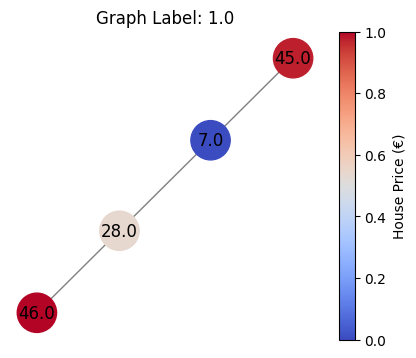

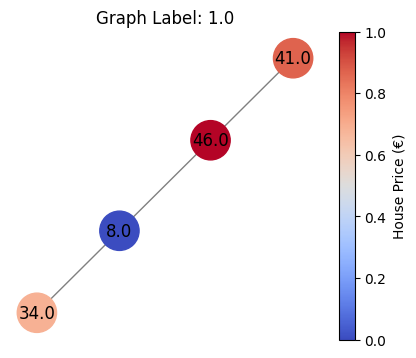

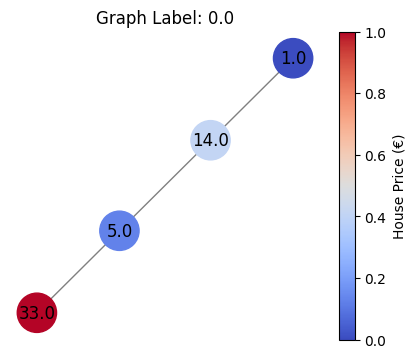

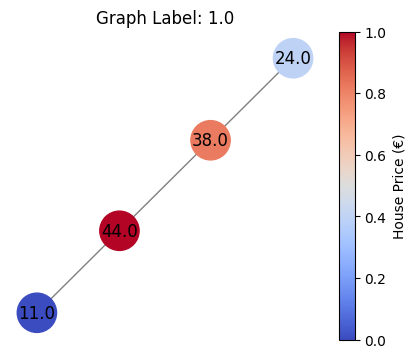

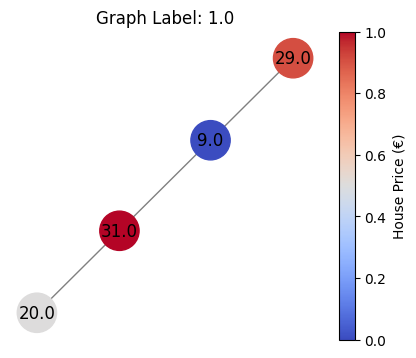

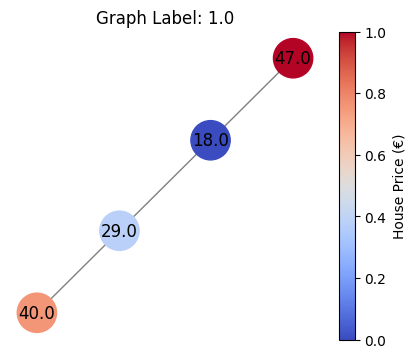

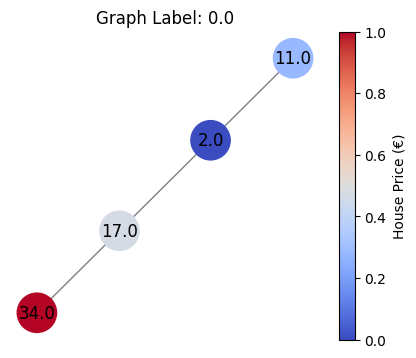

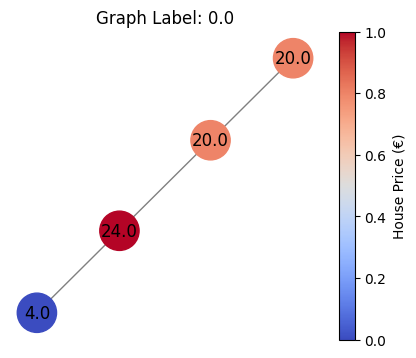

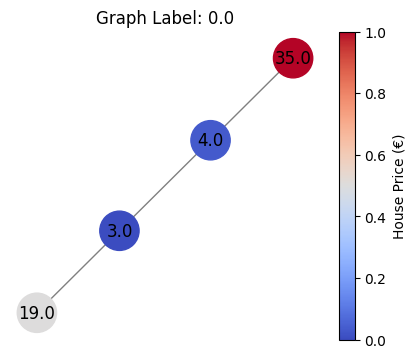

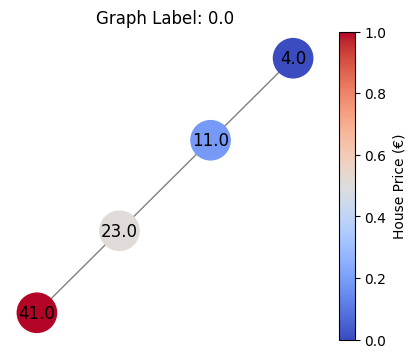

In [ ]:
checkpoint_path = path

checkpoint = torch.load(checkpoint_path, weights_only=True)
trained_model = GCN_Graph_Classifier(1, 50, 1)
trained_model.load_state_dict(checkpoint)

# threshold = 80

new_test_graphs, new_test_dataset = generate_many_graphs(10)

new_test_loader = DataLoader(new_test_dataset, batch_size=1, shuffle=False)

for data, g in zip(new_test_loader, new_test_graphs):
  #print(data)
  output, ge, ne = trained_model(data.x, data.edge_index, data.batch)
  pred = torch.round(torch.sigmoid(output))
  visualize_graph(g, graph_label=pred.item())


# Part 3: Autoencoder for similarity computation

## Training

In [ ]:
%load_ext tensorboard

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


In [ ]:
import torch
from torch.utils.tensorboard import SummaryWriter
writer = SummaryWriter()

In [ ]:
# Adapted and extended from https://github.com/pyg-team/pytorch_geometric/blob/master/examples/link_pred.py
# and https://pytorch-geometric.readthedocs.io/en/latest/_modules/torch_geometric/nn/models/autoencoder.html#InnerProductDecoder.forward

import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import roc_auc_score

from torch_geometric.nn import GCNConv
from torch_geometric.utils import to_dense_adj

import numpy as np

class GAE(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, latent_dim):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, latent_dim)

        self.mlp_feat = nn.Sequential(
            nn.Linear(1, 100),
            nn.ReLU(),
            nn.Linear(100, 1)
        )

    def encode(self, x, edge_index):
        h = self.conv1(x, edge_index)
        h = h.relu()
        h = self.conv2(h, edge_index)
        return h

    def decode_adj(self, z):
        # inner product decoder
        adj_pred = torch.sigmoid(z @ z.t())
        return adj_pred

    def decode_features(self, z):
        return self.mlp_feat(z)

    def forward(self, x, edge_index):
        z = self.encode(x, edge_index)
        adj_pred = self.decode_adj(z)
        feat_pred = self.decode_features(z)
        return z, adj_pred, feat_pred


bce = torch.nn.BCELoss()
mse = torch.nn.MSELoss()


def train():
    model.train()
    optimizer.zero_grad()

    total_loss = 0
    train_roc_auc = []

    for training_graph in dataset:

      z, adj_pred, feat_pred = model(training_graph.x, training_graph.edge_index)

      # structure reconstruction: the latent representation should preserve patterns of structural connections
      # nodes that are connected in the original graph are closer in the latent space
      adj_true = to_dense_adj(training_graph.edge_index, max_num_nodes=training_graph.num_nodes)[0]
      #print(graph.edge_index)
      #print("adjs ", adj_true.shape, adj_pred.shape)
      loss_adj = bce(adj_pred, adj_true)

      train_roc_auc.append(roc_auc_score(adj_true.cpu().detach().numpy().flatten(), adj_pred.cpu().detach().numpy().flatten()))

      # feature reconstruction: the latent representation should preserve the essential information in the node features
      # nodes that have similar attributes are closer in the latent space
      loss_feat = mse(training_graph.x, feat_pred)

      loss = loss_adj + loss_feat

      loss.backward()
      optimizer.step()

      total_loss += loss.item()

    return total_loss, train_roc_auc


@torch.no_grad()
def test(test_dataset):
    model.eval()

    errors = []
    roc_aucs = []

    for test_graph in test_dataset:
      z, out, feat = model(test_graph.x, test_graph.edge_index)
      mean_error_per_graph = np.mean(np.abs(test_graph.x.cpu().numpy() - feat.cpu().numpy()))

      true_adj = to_dense_adj(test_graph.edge_index, max_num_nodes=test_graph.num_nodes)[0].cpu()
      pred_adj = out.cpu().numpy()

      roc_auc_train_per_graph = roc_auc_score(true_adj.flatten(), pred_adj.flatten())

      errors.append(mean_error_per_graph)
      roc_aucs.append(roc_auc_train_per_graph)

    return errors, roc_aucs


n_epochs = 300 # 700 # 200 #700 #100 #300

if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')


model = GAE(1, 10, 1).to(device)
optimizer = torch.optim.Adam(params=model.parameters(), lr=0.0001) # 0.01 # 0.0001

test_graphs, test_dataset = generate_many_graphs(20)

# training + testing
for epoch in range(n_epochs):
    loss, train_roc_aucs = train()

    test_errors, test_roc_aucs = test(test_dataset)

    mean_error_test = np.mean(test_errors)
    mean_roc_auc_test = np.mean(test_roc_aucs)
    mean_roc_auc_train = np.mean(train_roc_aucs)

    writer.add_scalar("total_loss/gae", loss, epoch)
    writer.add_scalar("train_auc/gae", mean_roc_auc_train, epoch)
    writer.add_scalar("test_auc/gae", mean_roc_auc_test, epoch)
    writer.add_scalar("test_mean_error/gae", mean_error_test, epoch)

    if (epoch) % 10 == 0 or epoch == 0:
      print(f'Epoch: {epoch:03d}, Loss: {loss:.4f}, train roc auc: {mean_roc_auc_train:.4f},  test roc auc: {mean_roc_auc_test:.4f}, test mean error: {mean_error_test:.4f}')

Epoch: 000, Loss: 133767.3417, train roc auc: 0.6388,  test roc auc: 0.6000, test mean error: 19.4487
Epoch: 010, Loss: 31757.2211, train roc auc: 0.5050,  test roc auc: 0.5100, test mean error: 8.2591
Epoch: 020, Loss: 31963.0748, train roc auc: 0.5042,  test roc auc: 0.5100, test mean error: 8.2578
Epoch: 030, Loss: 35814.9411, train roc auc: 0.5049,  test roc auc: 0.5150, test mean error: 9.3515
Epoch: 040, Loss: 34076.7320, train roc auc: 0.5038,  test roc auc: 0.5150, test mean error: 9.2372
Epoch: 050, Loss: 32899.8315, train roc auc: 0.5020,  test roc auc: 0.5125, test mean error: 8.7204
Epoch: 060, Loss: 32844.1354, train roc auc: 0.5012,  test roc auc: 0.5158, test mean error: 8.6139
Epoch: 070, Loss: 33137.2865, train roc auc: 0.5015,  test roc auc: 0.5125, test mean error: 8.6822
Epoch: 080, Loss: 33274.0747, train roc auc: 0.5017,  test roc auc: 0.5125, test mean error: 8.7480
Epoch: 090, Loss: 33169.1422, train roc auc: 0.5017,  test roc auc: 0.5125, test mean error: 8.721

In [ ]:
writer.flush()
writer.close()

In [ ]:
!kill 1478

/bin/bash: line 1: kill: (1478) - No such process


In [ ]:
%tensorboard --logdir runs

## Graph embedding and similarity computation

--- Distance between g0 and g0:  0.0
--- Sums:  g0:  62.0; g0: 62.0


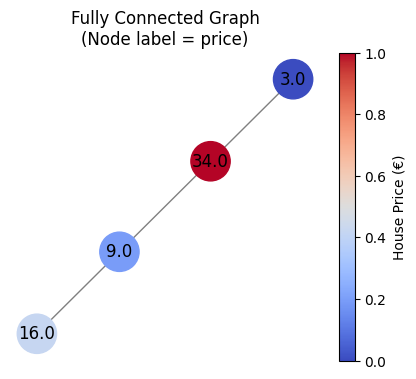

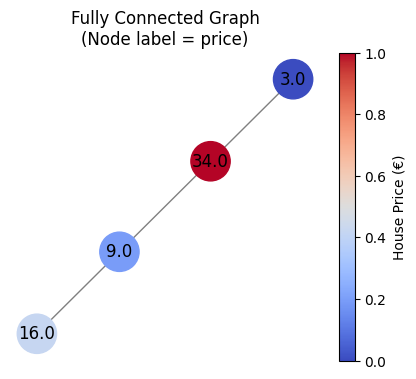

--- Distance between g0 and g1:  0.4758434295654297
--- Sums:  g0:  62.0; g1: 74.0


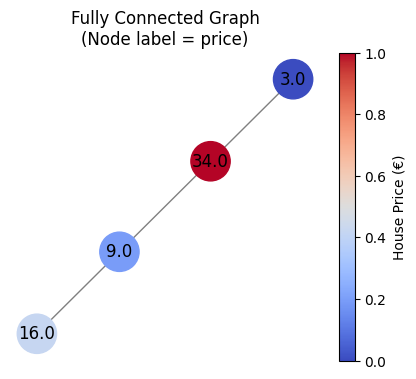

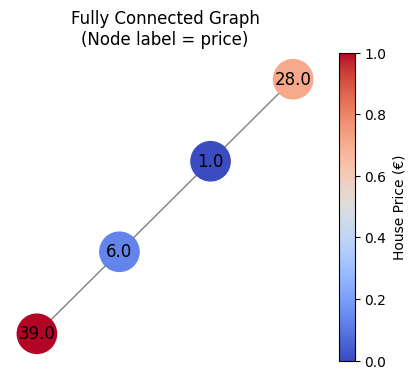

--- Distance between g0 and g2:  4.654506683349609
--- Sums:  g0:  62.0; g2: 101.0


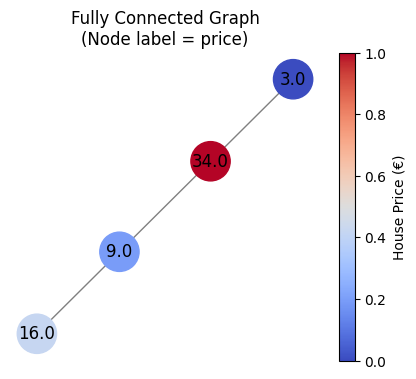

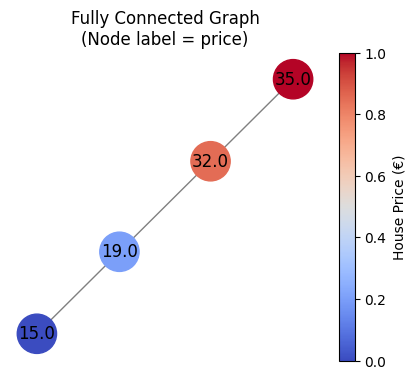

--- Distance between g0 and g3:  7.295652389526367
--- Sums:  g0:  62.0; g3: 120.0


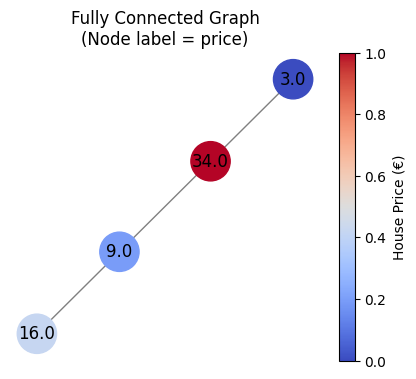

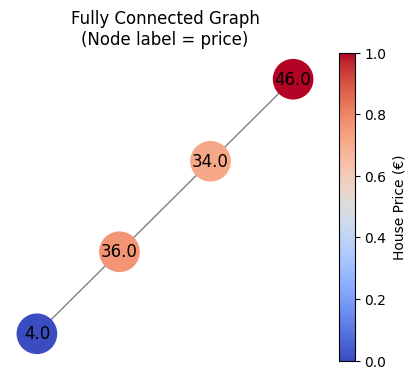

--- Distance between g1 and g0:  0.4758434295654297
--- Sums:  g1:  74.0; g0: 62.0


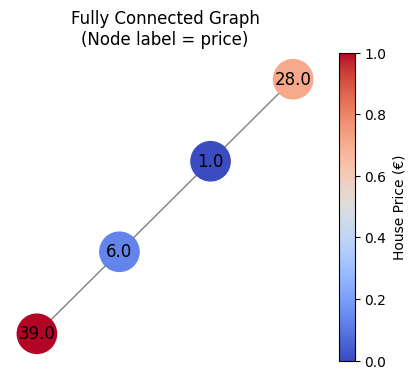

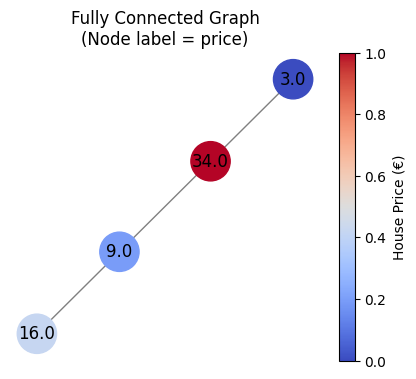

--- Distance between g1 and g1:  0.0
--- Sums:  g1:  74.0; g1: 74.0


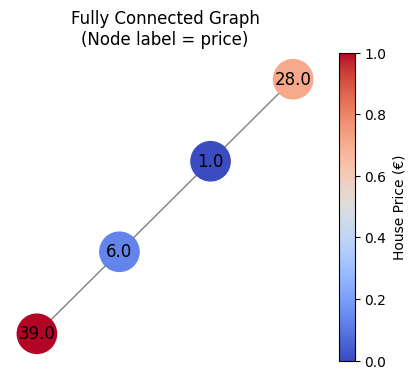

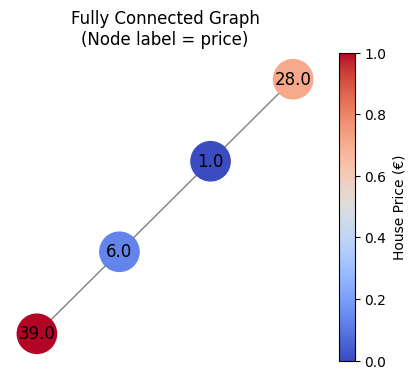

--- Distance between g1 and g2:  4.17866325378418
--- Sums:  g1:  74.0; g2: 101.0


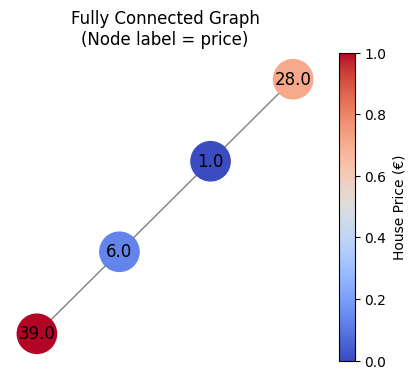

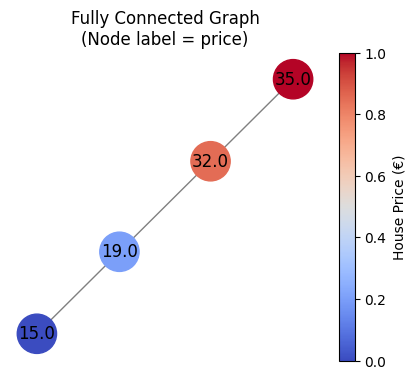

--- Distance between g1 and g3:  6.8198089599609375
--- Sums:  g1:  74.0; g3: 120.0


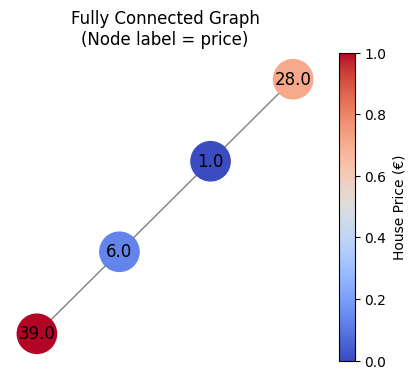

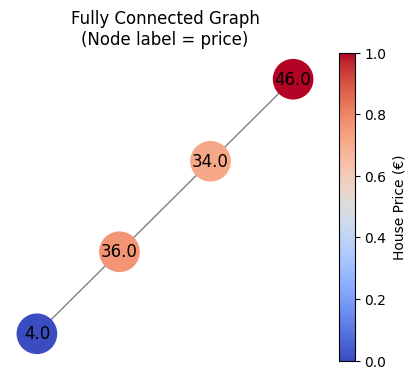

--- Distance between g2 and g0:  4.654506683349609
--- Sums:  g2:  101.0; g0: 62.0


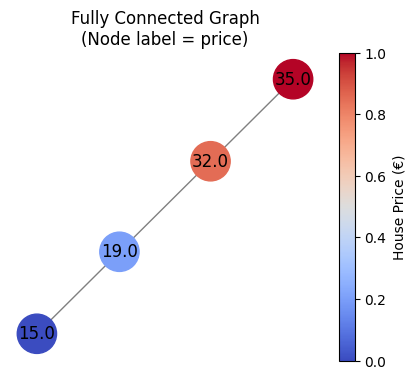

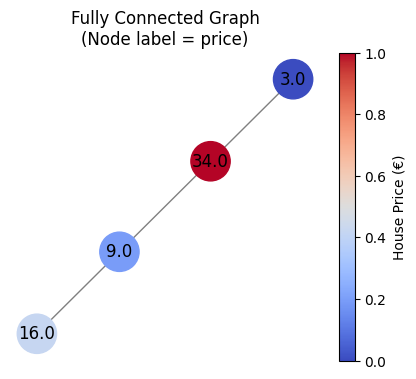

--- Distance between g2 and g1:  4.17866325378418
--- Sums:  g2:  101.0; g1: 74.0


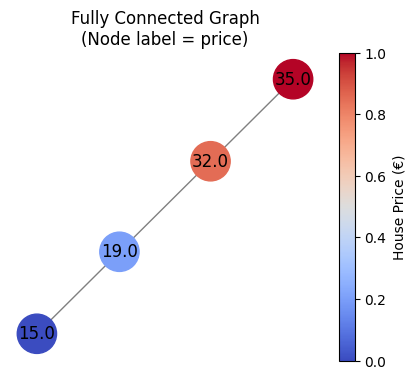

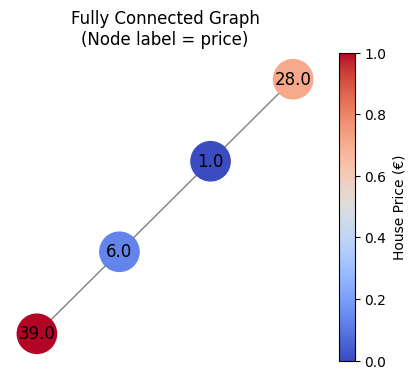

--- Distance between g2 and g2:  0.0
--- Sums:  g2:  101.0; g2: 101.0


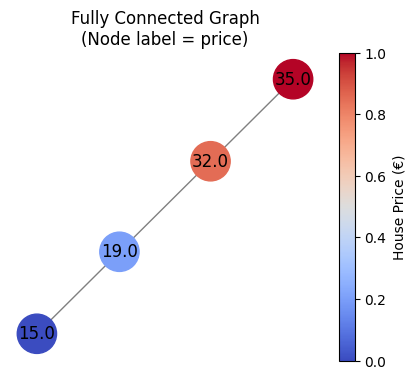

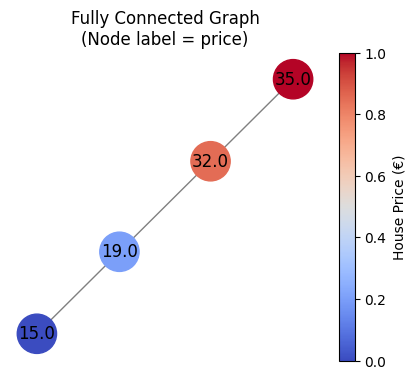

--- Distance between g2 and g3:  2.641145706176758
--- Sums:  g2:  101.0; g3: 120.0


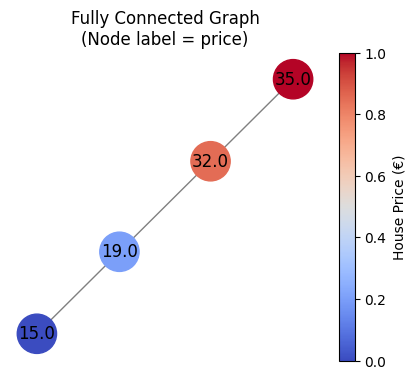

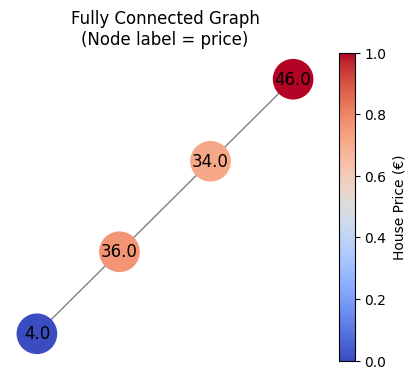

--- Distance between g3 and g0:  7.295652389526367
--- Sums:  g3:  120.0; g0: 62.0


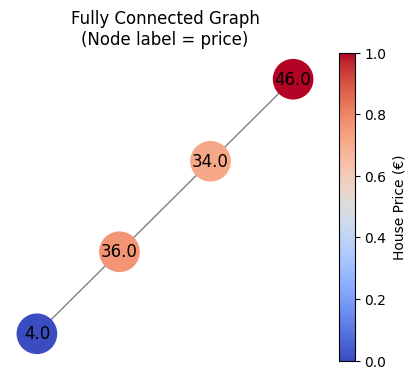

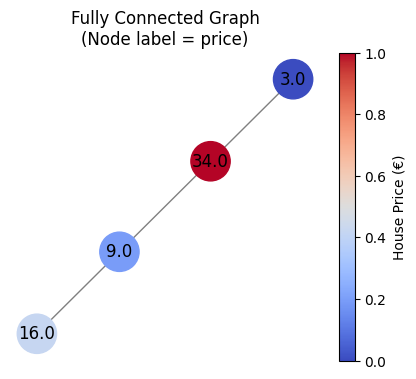

--- Distance between g3 and g1:  6.8198089599609375
--- Sums:  g3:  120.0; g1: 74.0


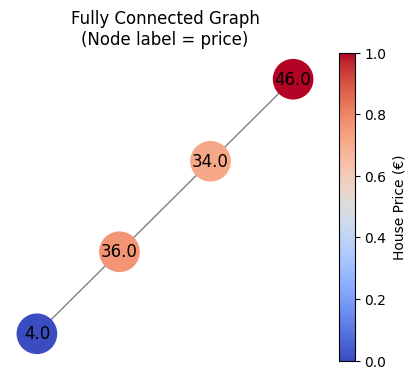

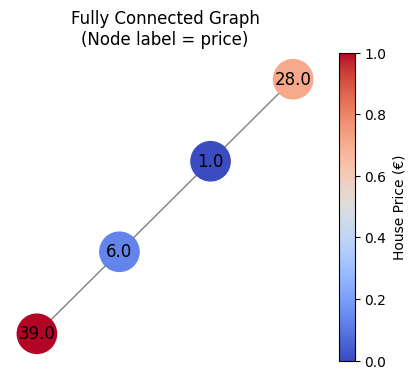

--- Distance between g3 and g2:  2.641145706176758
--- Sums:  g3:  120.0; g2: 101.0


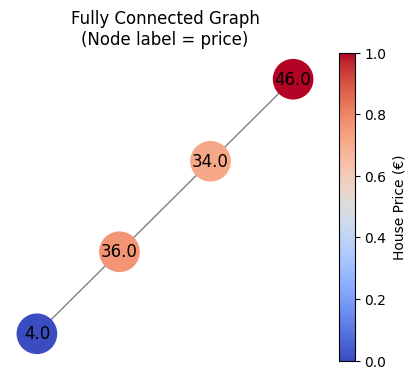

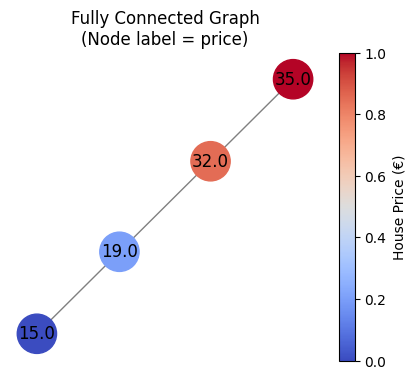

--- Distance between g3 and g3:  0.0
--- Sums:  g3:  120.0; g3: 120.0


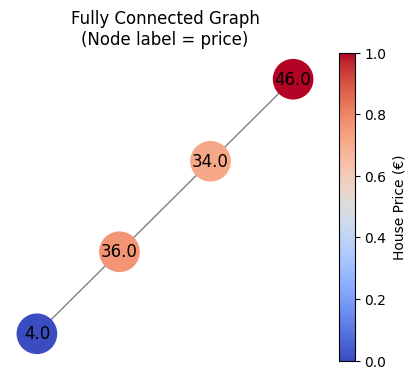

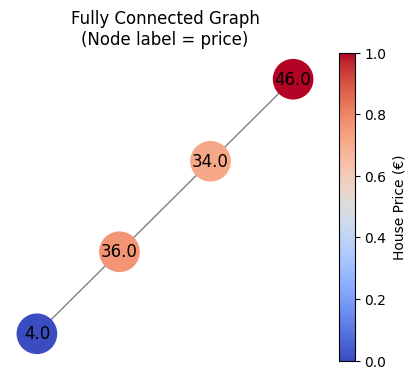

In [61]:
def graph_embedding(z, method="mean"):
    if method == "mean":
        return z.mean(dim=0)
    elif method == "sum":
        return z.sum(dim=0)
    elif method == "max":
        return z.max(dim=0)[0]

def graph_similarity(graph1, graph2, model):
    model.eval()
    with torch.no_grad():
        z1, _, _ = model(graph1.x, graph1.edge_index)
        z2, _, _ = model(graph2.x, graph2.edge_index)

        g1 = graph_embedding(z1)
        g2 = graph_embedding(z2)

        return torch.linalg.norm(g1 - g2).item()

trained_model = model

similarity_dict = {}
diff_dict = {}

new_test_graphs, new_test_dataset = generate_many_graphs(4)

for i in range(len(new_test_graphs)):
  for j in range(len(new_test_graphs)):

    g1 = new_test_graphs[i]
    g2 = new_test_graphs[j]

    g_d1 = new_test_dataset[i]
    g_d2 = new_test_dataset[j]

    string = "g"+str(i)+" and g"+str(j)
    similarity_dict[string] = graph_similarity(g_d1, g_d2, trained_model)
    diff_dict["diff g"+str(i)+" and g"+str(j)] = np.abs(g_d1.x.sum().item()- g_d2.x.sum().item()).item()

    print(f"--- Distance between {string}: ", graph_similarity(g_d1, g_d2, trained_model))
    print(f"--- Sums:  g{i}:  {g_d1.x.sum()}; g{j}: {g_d2.x.sum()}")

    visualize_graph(g1)
    visualize_graph(g2)

In [62]:
sorted_items = sorted(similarity_dict.items(), key=lambda item: item[1])
sorted_diff_items = sorted(diff_dict.items(), key=lambda item: item[1])

# Convert the sorted list of tuples back into a dictionary
sorted_dict = dict(sorted_items)
sorted_diff_dict = dict(sorted_diff_items)

sorted_dict, sorted_diff_dict

({'g0 and g0': 0.0,
  'g1 and g1': 0.0,
  'g2 and g2': 0.0,
  'g3 and g3': 0.0,
  'g0 and g1': 0.4758434295654297,
  'g1 and g0': 0.4758434295654297,
  'g2 and g3': 2.641145706176758,
  'g3 and g2': 2.641145706176758,
  'g1 and g2': 4.17866325378418,
  'g2 and g1': 4.17866325378418,
  'g0 and g2': 4.654506683349609,
  'g2 and g0': 4.654506683349609,
  'g1 and g3': 6.8198089599609375,
  'g3 and g1': 6.8198089599609375,
  'g0 and g3': 7.295652389526367,
  'g3 and g0': 7.295652389526367},
 {'diff g0 and g0': 0.0,
  'diff g1 and g1': 0.0,
  'diff g2 and g2': 0.0,
  'diff g3 and g3': 0.0,
  'diff g0 and g1': 12.0,
  'diff g1 and g0': 12.0,
  'diff g2 and g3': 19.0,
  'diff g3 and g2': 19.0,
  'diff g1 and g2': 27.0,
  'diff g2 and g1': 27.0,
  'diff g0 and g2': 39.0,
  'diff g2 and g0': 39.0,
  'diff g1 and g3': 46.0,
  'diff g3 and g1': 46.0,
  'diff g0 and g3': 58.0,
  'diff g3 and g0': 58.0})

# Project Work



*  EX01: Currently, all graphs have the same size, namely 4. Change the size to a random number and see the impact on the results
*  EX02: Change the conv layer (graph classification/graph autoencoder) to a gin layer and see the impact on the results
*  EX03: Use a variational graph autoencoder to learn a compressed latent-representation of the graphs
*  EX04: For the project, model your data as graphs, train an autoencoder or a variational autoencoder for similarity learning




Additional resources on Graph Classification
- [PyG Graph Classification Tutorial](https://colab.research.google.com/drive/1I8a0DfQ3fI7Njc62__mVXUlcAleUclnb?usp=sharing#scrollTo=CN3sRVuaQ88l)
- [PyG Point Cloud Classification Tutorial](https://colab.research.google.com/drive/1D45E5bUK3gQ40YpZo65ozs7hg5l-eo_U?usp=sharing)